SETUP THE NWB DATA

In [1]:
import sys
sys.path.insert(0, '/code/src')

import numpy as np
import pandas as pd
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt
from datetime import datetime

sns.set_theme(context='talk', style='ticks', palette='colorblind')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 'medium'
plt.rcParams['axes.titlelocation'] = 'left'

sns.set_context('talk')
pd.set_option('display.max_columns', None)

nwb_path = ('/data/dynamicrouting_datacube/'
        'ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/'
        '759434_2025-02-04.nwb.zarr')
session_id = '759434_2025-02-04'

session = pynwb.read_nwb(nwb_path)
trials = session.trials[:]
print('\n This session has %d trials' % len(trials))

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(



 This session has 545 trials


SETUP THE METADATA

In [2]:
from aind_data_access_api.document_db import MetadataDbClient

API_GATEWAY_HOST = 'api.allenneuraldynamics.org'
DATABASE = 'metadata_index'
COLLECTION = 'data_assets'

docdb_api_client = MetadataDbClient(host=API_GATEWAY_HOST, version='v2',
                                    database=DATABASE, collection=COLLECTION)

aggregate = [
    {'$match': {
        'data_description.project_name': 'Dynamic Routing',
        'data_description.data_level': 'derived',
        'processing.data_processes': {'$elemMatch': {
            'process_type': 'File format conversion',
            'start_date_time': {'$regex': '^2026-08-04'}}}}},
    {'$project': {
        'name': 1,
        'subject_id': '$data_description.subject_id',
        'genotype': '$subject.subject_details.genotype',
        'date_of_birth': '$subject.subject_details.date_of_birth',
        'sex': '$subject.subject_details.sex',
        'session_start_time': '$acquisition.acquisition_start_time',
        'session_end_time': '$acquisition.acquisition_end_time',
        'stimulus_epochs': '$acquisition.stimulus_epochs',
        'project_name': '$data_description.project_name',
        'modality': '$data_description.modalities.name',
        'targeted_structure': ('$acquisition.data_streams.configurations.probes'
                               '.primary_targeted_structure.name')}},
]

records = docdb_api_client.aggregate_docdb_records(pipeline=aggregate)
for r in records:
    dr = next((e for e in r.get('stimulus_epochs', [])
               if e.get('stimulus_name') == 'DynamicRouting1'), None)
    r['dr_performance'] = dr['performance_metrics'] if dr else None

metadata_df = pd.DataFrame(records)
metadata_df['trials_total'] = metadata_df['dr_performance'].apply(
    lambda x: x['trials_total'] if x else None)
metadata_df['trials_rewarded'] = metadata_df['dr_performance'].apply(
    lambda x: x['trials_rewarded'] if x else None)

# independent cross-check: these counts come from the metadata index, not the NWB file
this_session_row = metadata_df[metadata_df.name.str.contains(session_id, na=False)]
print('Metadata trials_total: %s, NWB trials: %d'
      % (this_session_row.trials_total.values, len(trials)))
print('Metadata trials_rewarded: %s, NWB is_rewarded: %d'
      % (this_session_row.trials_rewarded.values, trials.is_rewarded.sum()))
metadata_df.head(3)

Metadata trials_total: [545], NWB trials: 545
Metadata trials_rewarded: [142], NWB is_rewarded: 144


,_id,name,subject_id,genotype,date_of_birth,sex,session_start_time,session_end_time,stimulus_epochs,project_name,modality,targeted_structure,dr_performance,trials_total,trials_rewarded
0,c5bc8e0e-81ee-4e52-a7b6-90089b0dfc5f,ecephys_742903_2024-10-23_14-12-23_nwb_2026-08...,742903,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2024-05-16,Female,2024-10-23 14:12:23-07:00,2024-10-23 16:15:54.652646-07:00,"[{'object_type': 'Stimulus epoch', 'stimulus_s...",Dynamic Routing,"[Extracellular electrophysiology, Behavior, Be...","[[[Primary somatosensory area], [Caudoputamen]...","{'object_type': 'Performance metrics', 'output...",489,124
1,7f603b00-8b9f-4a66-8b9d-1d9ed27b40d4,ecephys_743199_2024-12-05_12-42-34_nwb_2026-08...,743199,VGAT-ChR2-YFP/wt,2024-05-18,Female,2024-12-05 12:42:34-08:00,2024-12-05 14:39:42.445214-08:00,"[{'object_type': 'Stimulus epoch', 'stimulus_s...",Dynamic Routing,"[Extracellular electrophysiology, Behavior, Be...","[[[Periaqueductal gray], [Red nucleus], [Red n...","{'object_type': 'Performance metrics', 'output...",490,132
2,66dc0f20-45dc-4a65-ac3a-0a04ac0e1df4,ecephys_662892_2023-08-24_14-28-28_nwb_2026-08...,662892,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2022-12-24,Female,2023-08-24 14:28:28-07:00,2023-08-24 16:28:14.588745-07:00,"[{'object_type': 'Stimulus epoch', 'stimulus_s...",Dynamic Routing,"[Extracellular electrophysiology, Behavior, Be...","[[[Piriform area], [root]]]","{'object_type': 'Performance metrics', 'output...",476,123


UNITS QUALITY CONTROL

In [ ]:
units_table = session.units[:]
print('This session has %d units before quality control' % len(units_table))

# QC thresholds
MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better

good_units = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO)
]

this_structure_units_table = good_units[good_units.structure == 'MOs']
print('%d good units in MOs' % len(this_structure_units_table))

This session has 2285 units before quality control
968 of 2285 units passed quality control
196 good units in MOs


SANITY CHECKS:

Is the first lick equal to response time?

In [24]:
licks = session.processing['behavior']['licks'][:]

lick_time_array = np.sort(licks['timestamps'].values.astype(float))
print('Number of licks: %d' % (lick_time_array.size))

# distance from each scored response to the nearest recorded lick
response_time_array = trials.loc[trials.is_response, 'response_time'].values.astype(float)
insert_index_array = np.clip(np.searchsorted(lick_time_array, response_time_array), 1, lick_time_array.size - 1)
nearest_offset_array = np.minimum(
    np.abs(response_time_array - lick_time_array[insert_index_array - 1]),
    np.abs(response_time_array - lick_time_array[insert_index_array]))

print('\n|response_time - nearest lick|: median %.2f ms, max %.2f ms'
      % (np.median(nearest_offset_array) * 1e3, nearest_offset_array.max() * 1e3))

Number of licks: 2353

|response_time - nearest lick|: median 0.00 ms, max 0.00 ms


How is the trial structure?

In [28]:
# Trial structure
print('Trial structure: go %d + nogo %d + catch %d = %d, total trials %d'
      % (trials.is_go.sum(), trials.is_nogo.sum(), trials.is_catch.sum(),
         trials.is_go.sum() + trials.is_nogo.sum() + trials.is_catch.sum(),
         len(trials)))
print('hit %d + miss %d = go %d'
      % (trials.is_hit.sum(), trials.is_miss.sum(), trials.is_go.sum()))
print('false alarm %d + correct reject %d = nogo %d'
      % (trials.is_false_alarm.sum(), trials.is_correct_reject.sum(),
         trials.is_nogo.sum()))

# Responses types
n_catch_response = (trials.is_catch & trials.is_response).sum()
print('\nhit %d + false alarm %d + catch response %d = %d, is_response %d'
      % (trials.is_hit.sum(), trials.is_false_alarm.sum(), n_catch_response,
         trials.is_hit.sum() + trials.is_false_alarm.sum() + n_catch_response,
         trials.is_response.sum()))

# Response window
window_start_offset = trials.response_window_start_time - trials.stim_start_time
window_stop_offset = trials.response_window_stop_time - trials.stim_start_time
print('\nresponse window start offset: %.4f to %.4f s (median %.4f)'
      % (window_start_offset.min(), window_start_offset.max(),
         window_start_offset.median()))
print('response window stop  offset: %.4f to %.4f s (median %.4f)'
      % (window_stop_offset.min(), window_stop_offset.max(),
         window_stop_offset.median()))

Trial structure: go 144 + nogo 353 + catch 48 = 545, total trials 545
hit 142 + miss 2 = go 144
false alarm 40 + correct reject 313 = nogo 353

hit 142 + false alarm 40 + catch response 1 = 183, is_response 183

response window start offset: 0.0555 to 0.0763 s (median 0.0560)
response window stop  offset: 0.9730 to 1.0103 s (median 0.9901)


COMPUTE THE REACTION TIME

In [31]:
# reaction time = response lick time - stimulus onset time, in seconds
trials['reaction_time'] = trials.response_time - trials.stim_start_time

# catch trials present no stimulus, so a stimulus-locked RT has no referent there.
rt_trial_mask = trials.is_response.copy()
rt_trial_mask &= ~trials.is_catch
print('Excluded %d catch response(s) from the RT analysis' % int((trials.is_response & trials.is_catch).sum()))

reaction_time_array = trials.loc[rt_trial_mask, 'reaction_time'].values
print('%d response trials analysed (of %d total responses)'
      % (reaction_time_array.size, int(trials.is_response.sum())))
print(pd.Series(reaction_time_array).describe())

print('\nnon-positive RTs: %d' % np.sum(reaction_time_array <= 0))
print('RTs outside the response window: %d'
      % np.sum((reaction_time_array < window_start_offset[rt_trial_mask].values) |
               (reaction_time_array > window_stop_offset[rt_trial_mask].values)))

Excluded 1 catch response(s) from the RT analysis
182 response trials analysed (of 183 total responses)
count    182.000000
mean       0.330899
std        0.140879
min        0.080810
25%        0.229212
50%        0.298720
75%        0.381246
max        0.908800
dtype: float64

non-positive RTs: 0
RTs outside the response window: 0


REACTION TIMES ANALYSIS

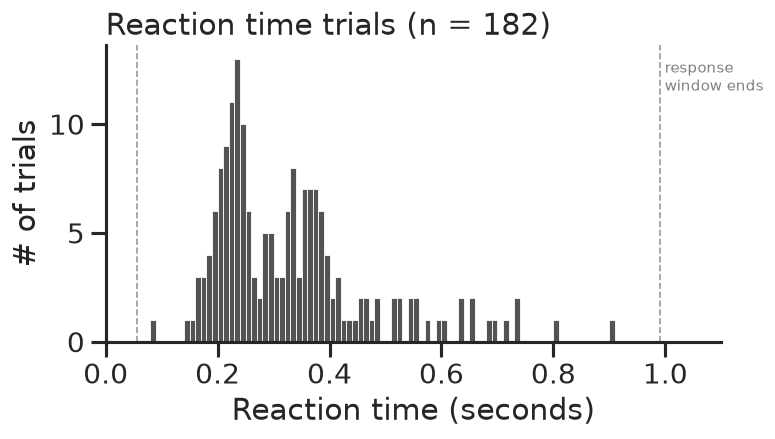

In [33]:
RT_BIN_WIDTH = 0.01          # 25 ms
RT_AXIS_LIMITS = (0, 1.1)     # display range

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(x=reaction_time_array, binwidth=RT_BIN_WIDTH, binrange=(0, RT_AXIS_LIMITS[1]),
             color='k', edgecolor='white', linewidth=0.5, ax=ax)

ax.axvline(window_start_offset.median(), color='0.6', lw=1, ls='--')
ax.axvline(window_stop_offset.median(), color='0.6', lw=1, ls='--')
ax.text(window_stop_offset.median(), ax.get_ylim()[1] * 0.95, ' response\n window ends',
        color='0.5', fontsize=9, va='top')

ax.set_xlim(*RT_AXIS_LIMITS)
ax.set_xlabel('Reaction time (seconds)')
ax.set_ylabel('# of trials')
ax.set_title('Reaction time trials (n = %d)' % (reaction_time_array.size))
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

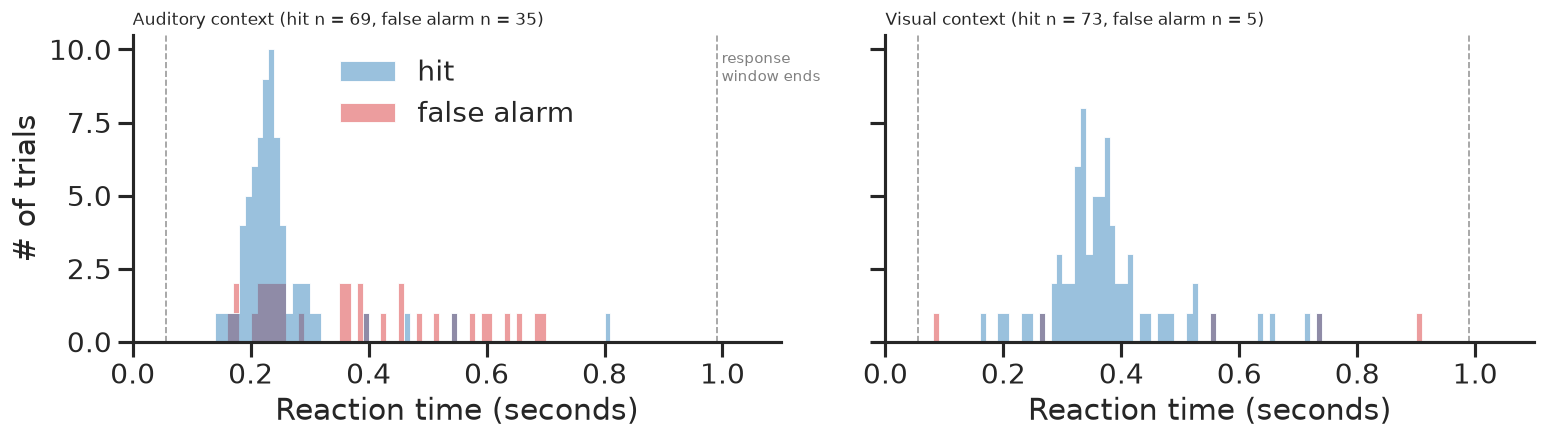

In [48]:
RT_BIN_WIDTH = 0.01           # 10 ms
RT_AXIS_LIMITS = (0, 1.1)     # display range

OUTCOME_COLORS = {'hit': 'tab:blue', 'false alarm': 'tab:red'}
RT_OUTCOMES = ['hit', 'false alarm']
CONTEXT_PANELS = [('aud', 'Auditory context'), ('vis', 'Visual context')]

rt_by_outcome_context = trials[rt_trial_mask
                               & trials.outcome.isin(RT_OUTCOMES)
                               & trials.reaction_time.notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)

for panel_index, (context_value, panel_title) in enumerate(CONTEXT_PANELS):
    ax = axes[panel_index]
    panel_data = rt_by_outcome_context[
        rt_by_outcome_context.rewarded_modality == context_value]

    sns.histplot(data=panel_data, x='reaction_time', hue='outcome',
                 hue_order=RT_OUTCOMES, palette=OUTCOME_COLORS,
                 binwidth=RT_BIN_WIDTH, binrange=(0, RT_AXIS_LIMITS[1]),
                 element='step', fill=True, alpha=0.45,
                 edgecolor='white', linewidth=0.5,
                 legend=(panel_index == 0), ax=ax)

    ax.axvline(window_start_offset.median(), color='0.6', lw=1, ls='--')
    ax.axvline(window_stop_offset.median(), color='0.6', lw=1, ls='--')

    ax.set_xlim(*RT_AXIS_LIMITS)
    ax.set_xlabel('Reaction time (seconds)')
    ax.set_title('%s (hit n = %d, false alarm n = %d)'
                 % (panel_title,
                    int((panel_data.outcome == 'hit').sum()),
                    int((panel_data.outcome == 'false alarm').sum())),
                 fontsize=10)
    sns.despine(ax=ax)

# shrink the legend seaborn attached to the left panel
legend = axes[0].get_legend()
legend.set_title('')
legend.prop.set_size(8)
legend.get_frame().set_linewidth(0)

axes[0].set_ylabel('# of trials')
axes[1].set_ylabel('')
axes[0].text(window_stop_offset.median(), axes[0].get_ylim()[1] * 0.95,
             ' response\n window ends', color='0.5', fontsize=9, va='top')
fig.tight_layout()
plt.show()

Visual stimuli discrimination requires more time to reach the brain than the auditory stimuli.Therefore, the reaction times are slower.

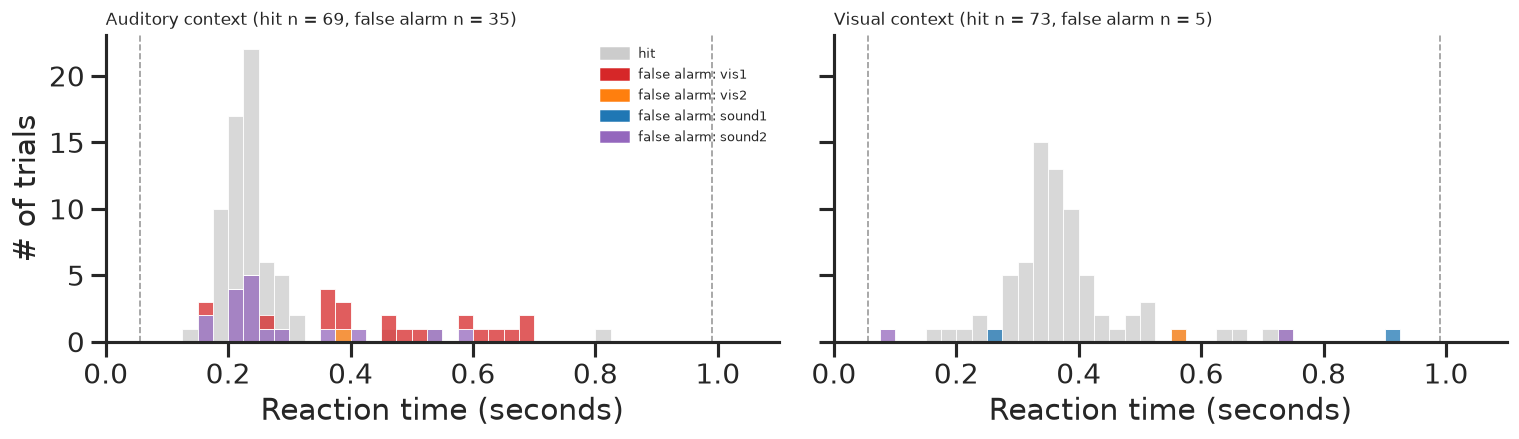

In [51]:
RT_BIN_WIDTH_FA = 0.025       # coarser 25 ms
FA_STIM_COLORS = {'vis1': 'tab:red', 'vis2': 'tab:orange',
                  'sound1': 'tab:blue', 'sound2': 'tab:purple'}
CONTEXT_PANELS = [('aud', 'Auditory context'), ('vis', 'Visual context')]

false_alarm_trials = trials[rt_trial_mask & trials.is_false_alarm
                            & trials.reaction_time.notna()]

# one hue order across both panels, so a colour means the same thing on each side
fa_stim_present = [s for s in FA_STIM_COLORS if s in set(false_alarm_trials.stim_name)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)

for panel_index, (context_value, panel_title) in enumerate(CONTEXT_PANELS):
    ax = axes[panel_index]
    panel_hits = trials[rt_trial_mask & trials.is_hit
                        & (trials.rewarded_modality == context_value)]
    panel_fa = false_alarm_trials[
        false_alarm_trials.rewarded_modality == context_value]

    # hits as a grey backdrop, so the false alarms are the readable layer
    sns.histplot(x=panel_hits.reaction_time, binwidth=RT_BIN_WIDTH_FA,
                 binrange=(0, RT_AXIS_LIMITS[1]), color='0.8',
                 edgecolor='white', linewidth=0.5, ax=ax)
    sns.histplot(data=panel_fa, x='reaction_time', hue='stim_name',
                 hue_order=fa_stim_present, palette=FA_STIM_COLORS,
                 multiple='stack', binwidth=RT_BIN_WIDTH_FA,
                 binrange=(0, RT_AXIS_LIMITS[1]),
                 edgecolor='white', linewidth=0.5, legend=False, ax=ax)

    ax.axvline(window_start_offset.median(), color='0.6', lw=1, ls='--')
    ax.axvline(window_stop_offset.median(), color='0.6', lw=1, ls='--')
    ax.set_xlim(*RT_AXIS_LIMITS)
    ax.set_xlabel('Reaction time (seconds)')
    ax.set_title('%s (hit n = %d, false alarm n = %d)'
                 % (panel_title, len(panel_hits), len(panel_fa)), fontsize=10)
    sns.despine(ax=ax)

# legend built by hand: covers every stimulus in the data, not just the left panel
from matplotlib.patches import Patch
legend_handles = ([Patch(color='0.8', label='hit')]
                  + [Patch(color=FA_STIM_COLORS[s], label='false alarm: %s' % s)
                     for s in fa_stim_present])
axes[0].legend(handles=legend_handles, fontsize=8, frameon=False, loc='upper right')

axes[0].set_ylabel('# of trials')
axes[1].set_ylabel('')
fig.tight_layout()
plt.show()

False alarms are also related with the stimuli.

REACTION TIME AND MOTIVATION ANALYSIS

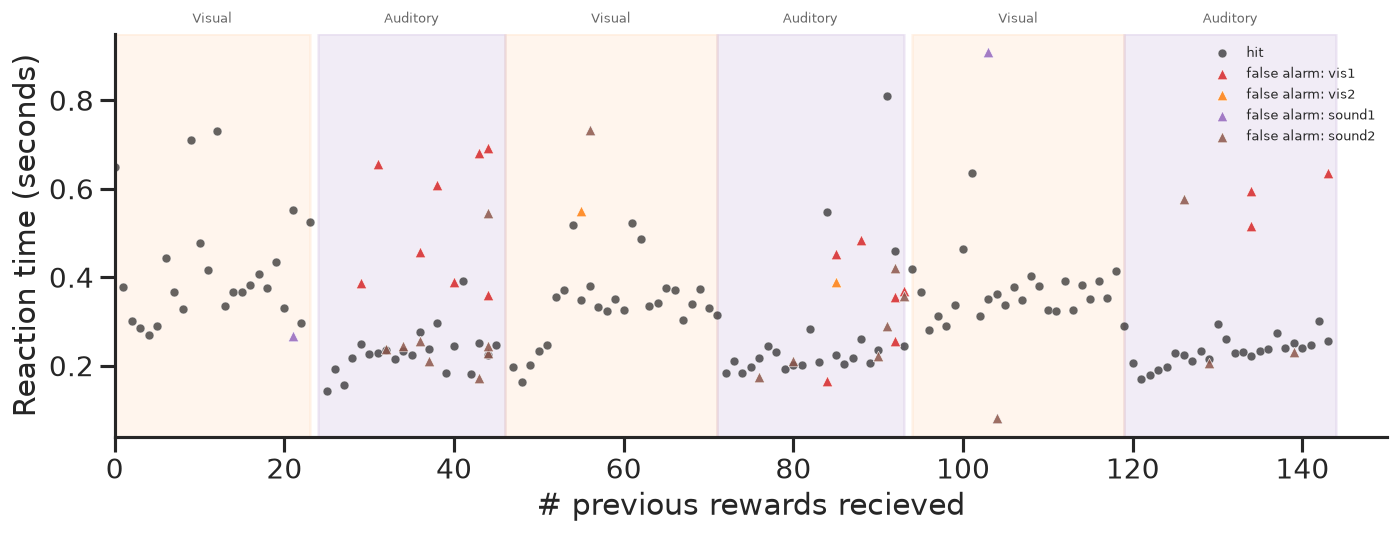

In [72]:
# rewards received strictly before the current trial
trials['n_previous_rewards'] = trials.is_rewarded.cumsum().shift(1).fillna(0).astype(int)

rt_scatter_data = trials[rt_trial_mask & trials.outcome.isin(RT_OUTCOMES)
                         & trials.reaction_time.notna()]

CONTEXT_SHADE = {'vis': ('tab:orange', 0.07), 'aud': ('tab:purple', 0.12)}
CONTEXT_LABELS = {'vis': 'Visual', 'aud': 'Auditory'}
HIT_COLOR = 'black'
FA_STIM_COLORS = {'vis1': 'tab:red', 'vis2': 'tab:orange',
                  'sound1': 'tab:purple', 'sound2': 'tab:brown'}

fig, ax = plt.subplots(figsize=(12, 4.8))

# --- block bands, in x = cumulative rewards --------------------------------
for block_index, block_trials in trials.groupby('block_index'):
    band_start = block_trials.n_previous_rewards.min()
    band_stop = block_trials.n_previous_rewards.max()
    block_context = block_trials.rewarded_modality.iloc[0]
    shade_color, shade_alpha = CONTEXT_SHADE[block_context]
    ax.axvspan(band_start, band_stop, color=shade_color, alpha=shade_alpha, zorder=0)
    ax.annotate(CONTEXT_LABELS[block_context],
                ((band_start + band_stop) / 2, 1.02),
                xycoords=('data', 'axes fraction'),
                ha='center', va='bottom', fontsize=8, color='0.4')

# --- hits: circles, one colour (the stimulus is always the block target) -----
hit_data = rt_scatter_data[rt_scatter_data.outcome == 'hit']
ax.scatter(hit_data.n_previous_rewards, hit_data.reaction_time,
           s=28, alpha=0.6, marker='o', color=HIT_COLOR,
           edgecolor='white', linewidth=0.4, zorder=2, label='hit')

# --- false alarms: triangles, coloured by the stimulus licked to -------------
fa_data = rt_scatter_data[rt_scatter_data.outcome == 'false alarm']
for stim_name in [s for s in FA_STIM_COLORS if s in set(fa_data.stim_name)]:
    stim_subset = fa_data[fa_data.stim_name == stim_name]
    ax.scatter(stim_subset.n_previous_rewards, stim_subset.reaction_time,
               s=40, alpha=0.85, marker='^', color=FA_STIM_COLORS[stim_name],
               edgecolor='white', linewidth=0.4, zorder=3,
               label='false alarm: %s' % stim_name)

ax.set_xlabel('# previous rewards recieved')
ax.set_ylabel('Reaction time (seconds)')
ax.legend(fontsize=8, frameon=False, ncol=1, loc='upper right')
ax.set_xlim(0,150)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

streaks computed over go trials (n = 144)
consecutive_rewarded: median 72, max 143
consecutive_unrewarded: median 0, max 0
unrewarded streak > 0 on 0 of 144 trials


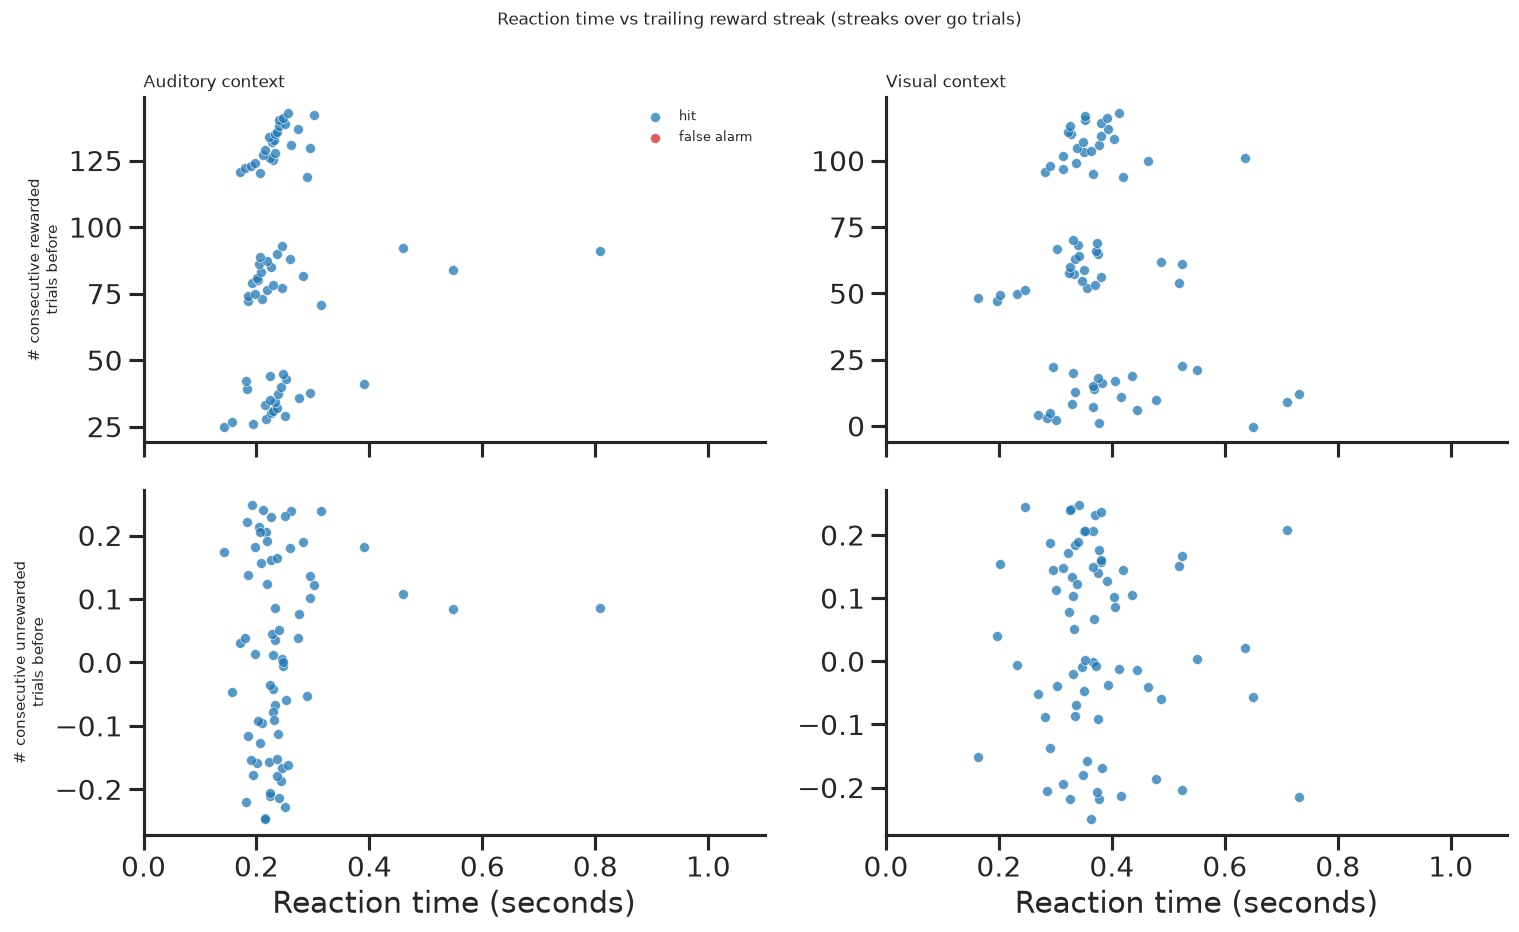

In [58]:
STREAK_TRIAL_SUBSET = 'go'     # 'go' = rewardable trials only; 'all' = every trial


def trailing_streak(flag_array):
    """Number of consecutive True values immediately preceding each position."""
    streak = np.zeros(len(flag_array), dtype=int)
    run_length = 0
    for position, flag in enumerate(flag_array):
        streak[position] = run_length
        run_length = run_length + 1 if flag else 0
    return streak


streak_mask = (trials.is_go if STREAK_TRIAL_SUBSET == 'go'
               else pd.Series(True, index=trials.index))
streak_source = trials[streak_mask]
rewarded_flag = streak_source.is_rewarded.values

trials['consecutive_rewarded'] = np.nan
trials['consecutive_unrewarded'] = np.nan
trials.loc[streak_mask, 'consecutive_rewarded'] = trailing_streak(rewarded_flag)
trials.loc[streak_mask, 'consecutive_unrewarded'] = trailing_streak(~rewarded_flag)

print('streaks computed over %s trials (n = %d)'
      % (STREAK_TRIAL_SUBSET, int(streak_mask.sum())))
print('consecutive_rewarded: median %.0f, max %.0f'
      % (trials.consecutive_rewarded.median(), trials.consecutive_rewarded.max()))
print('consecutive_unrewarded: median %.0f, max %.0f'
      % (trials.consecutive_unrewarded.median(), trials.consecutive_unrewarded.max()))
print('unrewarded streak > 0 on %d of %d trials'
      % (int((trials.consecutive_unrewarded > 0).sum()), int(streak_mask.sum())))

streak_data = trials[rt_trial_mask & trials.reaction_time.notna()
                     & trials.consecutive_rewarded.notna()]

STREAK_ROWS = [('consecutive_rewarded', '# consecutive rewarded\ntrials before'),
               ('consecutive_unrewarded', '# consecutive unrewarded\ntrials before')]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
rng = np.random.default_rng(0)

for row_index, (streak_column, row_label) in enumerate(STREAK_ROWS):
    for col_index, (context_value, panel_title) in enumerate(CONTEXT_PANELS):
        ax = axes[row_index, col_index]
        panel_data = streak_data[streak_data.rewarded_modality == context_value]

        # vertical jitter: the streak is an integer, so points would overlap exactly
        jitter = rng.uniform(-0.25, 0.25, len(panel_data))
        for outcome_label in RT_OUTCOMES:
            outcome_mask = (panel_data.outcome == outcome_label).values
            ax.scatter(panel_data.reaction_time.values[outcome_mask],
                       panel_data[streak_column].values[outcome_mask]
                       + jitter[outcome_mask],
                       s=35, alpha=0.75, edgecolor='white', linewidth=0.4,
                       color=OUTCOME_COLORS[outcome_label],
                       label=outcome_label if (row_index == 0 and col_index == 0)
                       else None)

        ax.set_xlim(*RT_AXIS_LIMITS)
        if row_index == 0:
            ax.set_title(panel_title, fontsize=10)
        if row_index == 1:
            ax.set_xlabel('Reaction time (seconds)')
        ax.set_ylabel(row_label if col_index == 0 else '', fontsize=9)
        sns.despine(ax=ax)

axes[0, 0].legend(fontsize=8, frameon=False, loc='upper right')
fig.suptitle('Reaction time vs trailing reward streak (streaks over %s trials)'
             % STREAK_TRIAL_SUBSET, fontsize=10)
fig.tight_layout()
plt.show()

SETUP BEHAVIOR DATA

In [68]:
behavior_module = session.processing['behavior']
print('behavior module contents: %s\n' % list(behavior_module.data_interfaces.keys()))

def summarise_timestamps(name, timestamp_array):
    """Sampling regularity and coverage of one behavioral stream."""
    timestamp_array = np.asarray(timestamp_array, dtype=float)
    finite = timestamp_array[np.isfinite(timestamp_array)]
    step_array = np.diff(finite)
    median_step = np.median(step_array)
    n_gap = np.sum(step_array > 2 * median_step)
    print('%-22s n=%7d  %.1f-%.1f s  median step %.4f s (%.1f Hz)  '
          'gaps>2x: %d (max %.3f s)  non-finite: %d'
          % (name, timestamp_array.size, finite.min(), finite.max(),
             median_step, 1 / median_step, n_gap, step_array.max(),
             timestamp_array.size - finite.size))

running_series = behavior_module['running_speed']
running_timestamps = running_series.timestamps[:]
running_speed = running_series.data[:]
summarise_timestamps('running_speed', running_timestamps)

side_camera_df = behavior_module['lp_side_camera'][:]
summarise_timestamps('lp_side_camera', side_camera_df['timestamps'].values)

eye_df = behavior_module['eye_tracking'][:]
summarise_timestamps('eye_tracking', eye_df['timestamps'].values)

rewards_df = behavior_module['rewards'][:]
print('\nrewards: n=%d, is_solenoid_time: %s, duration median %.4f s'
      % (len(rewards_df), rewards_df.is_solenoid_time.unique(),
         rewards_df.duration.median()))

behavior module contents: ['facemap_front_camera', 'facemap_side_camera', 'running_speed', 'dlc_eye_camera', 'eye_tracking', 'licks', 'lp_front_camera', 'lp_side_camera', 'quiescent_interval_violations', 'rewards']

running_speed          n= 412214  45.6-7023.4 s  median step 0.0167 s (60.0 Hz)  gaps>2x: 1522 (max 11.226 s)  non-finite: 0
lp_side_camera         n= 420666  14.2-7025.2 s  median step 0.0167 s (60.0 Hz)  gaps>2x: 2 (max 0.117 s)  non-finite: 1
eye_tracking           n= 420655  14.4-7025.3 s  median step 0.0167 s (60.0 Hz)  gaps>2x: 2 (max 0.117 s)  non-finite: 1

rewards: n=156, is_solenoid_time: [ True], duration median 0.0421 s


In [69]:
def get_binned_triggered_spike_counts_fast(spike_times, stim_times, bins):
    """Workshop helper: spike counts per trial per bin, via searchsorted."""
    spike_times = np.asarray(spike_times)
    stim_times = np.asarray(stim_times)
    bins = np.asarray(bins)
    counts = np.zeros((stim_times.size, bins.size - 1), dtype=int)
    for i, stim in enumerate(stim_times):
        spikes_before_edge = np.searchsorted(spike_times, stim + bins, side='left')
        counts[i, :] = np.diff(spikes_before_edge)
    return counts


# every MOs unit should observe the whole session, or rates need masking
print('units with more than one obs interval: %d'
      % sum(len(iv) > 1 for iv in this_structure_units_table.obs_intervals.values))
print('MOs firing_rate: median %.2f Hz, range %.2f-%.2f Hz'
      % (this_structure_units_table.firing_rate.median(),
         this_structure_units_table.firing_rate.min(),
         this_structure_units_table.firing_rate.max()))

units with more than one obs interval: 0
MOs firing_rate: median 1.98 Hz, range 0.10-22.88 Hz


In [70]:
epochs_df = session.epochs[:]
print(epochs_df[['start_time', 'stop_time', 'script_name', 'tags']].to_string())

# SpontaneousRewards epochs bracket the task and deliver free rewards every 90.5 s.
# Those are not task rewards and must not drive time-since-reward in Step 5.
TASK_START = float(trials.start_time.min())
TASK_STOP = float(trials.stop_time.max())

all_reward_time_array = np.sort(rewards_df.timestamps.values)
in_task_mask = ((all_reward_time_array >= TASK_START)
                & (all_reward_time_array <= TASK_STOP))
task_reward_time_array = all_reward_time_array[in_task_mask]

print('\ntask trials span %.1f-%.1f s' % (TASK_START, TASK_STOP))
print('rewards inside task epoch: %d, outside: %d'
      % (task_reward_time_array.size, (~in_task_mask).sum()))
print('in-task rewards vs trials with reward_time: %d vs %d'
      % (task_reward_time_array.size, trials.reward_time.notna().sum()))

    start_time    stop_time         script_name                    tags
id                                                                     
0     45.62740   916.491240           RFMapping               [mapping]
1    927.69937  1530.872170         Spontaneous           [spontaneous]
2   1541.98091  2145.086620  SpontaneousRewards  [rewards, spontaneous]
3   2155.69515  5796.812075     DynamicRouting1         [task, rewards]
4   5806.68705  6409.775485  SpontaneousRewards  [rewards, spontaneous]
5   6420.33438  7023.406090         Spontaneous           [spontaneous]

task trials span 2158.9-5795.1 s
rewards inside task epoch: 144, outside: 12
in-task rewards vs trials with reward_time: 144 vs 144


In [84]:
WINDOW_DURATION = 50.0      # seconds
BIN_WIDTH = 0.020           # 20 ms bins for the population rate
REQUIRE_SINGLE_BLOCK = True     # no context switch inside the window
EXCLUDE_INSTRUCTION = True      # instruction trials are atypical priming trials
MIN_TRIALS_ELAPSED = 50         # skip the start of the session

stim_start_array = trials.stim_start_time.values
candidate_start_array = stim_start_array - 1.0

candidate_df = pd.DataFrame({
    'window_start': candidate_start_array,
    'trial_index': trials.trial_index.values,
    'n_rewards': [np.sum((task_reward_time_array >= t)
                         & (task_reward_time_array < t + WINDOW_DURATION))
                  for t in candidate_start_array],
    'n_trials': [np.sum((stim_start_array >= t)
                        & (stim_start_array < t + WINDOW_DURATION))
                 for t in candidate_start_array],
    'n_contexts': [trials.loc[(stim_start_array >= t)
                              & (stim_start_array < t + WINDOW_DURATION),
                              'rewarded_modality'].nunique()
                   for t in candidate_start_array],
    'n_instruction': [trials.loc[(stim_start_array >= t)
                                 & (stim_start_array < t + WINDOW_DURATION),
                                 'is_instruction'].sum()
                      for t in candidate_start_array],
    'block_index': trials.block_index.values,
    'context': trials.rewarded_modality.values,
})

selection_mask = candidate_df.trial_index >= MIN_TRIALS_ELAPSED
if REQUIRE_SINGLE_BLOCK:
    selection_mask &= candidate_df.n_contexts == 1
if EXCLUDE_INSTRUCTION:
    selection_mask &= candidate_df.n_instruction == 0
candidate_df = candidate_df[selection_mask].sort_values(
    ['n_rewards', 'n_trials'], ascending=False)

print(candidate_df.head(10).to_string(index=False))

WINDOW_START = float(candidate_df.window_start.iloc[0])
WINDOW_STOP = WINDOW_START + WINDOW_DURATION
assert np.isclose(WINDOW_STOP - WINDOW_START, WINDOW_DURATION), 'window duration mismatch'

window_trials = trials.loc[(trials.stim_start_time >= WINDOW_START)
                           & (trials.stim_start_time < WINDOW_STOP)]
print('\nselected window: %.2f-%.2f s' % (WINDOW_START, WINDOW_STOP))
print(window_trials[['stim_name', 'outcome', 'rewarded_modality',
                     'stim_start_time', 'reaction_time', 'reward_time']].to_string())

 window_start  trial_index  n_rewards  n_trials  n_contexts  n_instruction  block_index context
  5559.564170          508          5         8           1              0            5     aud
  5566.216150          509          5         8           1              0            5     aud
  4027.297360          277          4         8           1              0            3     aud
  4033.669310          278          4         8           1              0            3     aud
  4040.872580          279          4         8           1              0            3     aud
  5572.704830          510          4         8           1              0            5     aud
  5550.971010          507          4         7           1              0            5     aud
  3614.601545          216          4         6           1              0            2     vis
  2922.605505          115          3         9           1              0            1     aud
  2928.156520          116          3   

In [85]:
SIDE_CAMERA_FRAME_HEIGHT = 492    # workshop convention for flipping y
KEYPOINT_LIKELIHOOD_MIN = 0.99
MAX_GAP_TO_DRAW = 0.100           # s; longer NaN runs stay broken in the plot


def get_facial_feature_masked(part_name, facial_features_df,
                              frame_height=SIDE_CAMERA_FRAME_HEIGHT,
                              likelihood_min=KEYPOINT_LIKELIHOOD_MIN):
    """Vertical keypoint position, unreliable samples set to NaN.

    Same masking as the workshop's get_facial_feature, WITHOUT its final
    ffill/bfill: filling would draw a flat line through tracking dropouts,
    indistinguishable from genuine immobility in a time-resolved trace.
    Statistics use the whole session, so centering is window-independent.
    """
    confidence = facial_features_df['%s_likelihood' % part_name]
    temporal_norm = facial_features_df['%s_temporal_norm' % part_name]

    y = frame_height - facial_features_df['%s_y' % part_name].astype(float)
    y[(confidence < likelihood_min)
      | (temporal_norm > np.nanmean(temporal_norm) + 2 * np.nanstd(temporal_norm))] = np.nan

    y_centered = y - np.nanmean(y)
    y_abs_centered = np.abs(y_centered)
    y_centered[y_abs_centered > np.nanmean(y_abs_centered)
               + 2 * np.nanstd(y_abs_centered)] = np.nan
    return y_centered.to_numpy()


def crop_to_window(timestamp_array, value_array, window_start, window_stop):
    """Samples inside [window_start, window_stop). Timestamps are never modified."""
    t = np.asarray(timestamp_array, dtype=float)
    in_window = (t >= window_start) & (t < window_stop)
    return t[in_window], np.asarray(value_array, dtype=float)[in_window]


def break_long_gaps(timestamp_array, value_array, max_gap=MAX_GAP_TO_DRAW):
    """Insert NaN across sampling gaps so the line breaks instead of interpolating."""
    gap_index = np.flatnonzero(np.diff(timestamp_array) > max_gap)
    if gap_index.size == 0:
        return timestamp_array, value_array
    return (np.insert(timestamp_array, gap_index + 1, np.nan),
            np.insert(value_array, gap_index + 1, np.nan))


def population_mean_rate(units_subset, window_start, window_stop, bin_width):
    """Mean firing rate across units in spikes/s per neuron, on a fixed grid."""
    relative_edges = np.arange(0, window_stop - window_start + bin_width, bin_width)
    count_array = np.zeros((len(units_subset), relative_edges.size - 1))
    for row_index, spike_time_array in enumerate(units_subset.spike_times.values):
        count_array[row_index] = get_binned_triggered_spike_counts_fast(
            spike_time_array, [window_start], relative_edges)[0]
    bin_center_array = window_start + relative_edges[:-1] + bin_width / 2
    return bin_center_array, count_array.mean(axis=0) / bin_width


def boxcar_smooth(value_array, n_bins):
    """Centered moving average. n_bins <= 1 returns the input unchanged."""
    if n_bins <= 1:
        return value_array
    return np.convolve(value_array, np.ones(n_bins) / n_bins, mode='same')

In [86]:
SMOOTH_BINS = 5    # 5 x 20 ms = 100 ms boxcar on the population rate

# --- neural: MOs population mean rate ----------------------------------------
rate_time, mos_rate = population_mean_rate(
    this_structure_units_table, WINDOW_START, WINDOW_STOP, BIN_WIDTH)
mos_rate_smoothed = boxcar_smooth(mos_rate, SMOOTH_BINS)

# robustness check: the file's own QC flag instead of the workshop thresholds
strict_units = units_table[units_table.is_qc_pass & (units_table.structure == 'MOs')]
_, mos_rate_strict = population_mean_rate(
    strict_units, WINDOW_START, WINDOW_STOP, BIN_WIDTH)
print('MOs units: %d (workshop QC) vs %d (is_qc_pass), rate correlation %.3f'
      % (len(this_structure_units_table), len(strict_units),
         np.corrcoef(mos_rate, mos_rate_strict)[0, 1]))

# --- behavior: each stream keeps its own timestamps, no resampling ------------
window_streams = {}

t, v = crop_to_window(running_timestamps, running_speed, WINDOW_START, WINDOW_STOP)
window_streams['Running speed\n(cm/s)'] = break_long_gaps(t, v)

pupil_area = eye_df['pupil_area'].astype(float).to_numpy().copy()
pupil_area[eye_df['pupil_is_bad_frame'].to_numpy().astype(bool)] = np.nan
t, v = crop_to_window(eye_df['timestamps'].values, pupil_area, WINDOW_START, WINDOW_STOP)
window_streams['Pupil area\n(px$^2$)'] = break_long_gaps(t, v)

side_camera_timestamps = side_camera_df['timestamps'].values
for panel_label, keypoint_name in [('Ear\n(px)', 'ear_base_l'),
                                   ('Whisker pad\n(px)', 'whisker_pad_l_side'),
                                   ('Jaw\n(px)', 'jaw')]:
    y = get_facial_feature_masked(keypoint_name, side_camera_df)
    t, v = crop_to_window(side_camera_timestamps, y, WINDOW_START, WINDOW_STOP)
    window_streams[panel_label] = break_long_gaps(t, v)

print('')
for panel_label, (t, v) in window_streams.items():
    print('%-22s %d samples, %.1f%% NaN after masking'
          % (panel_label.replace('\n', ' '), v.size, 100 * np.isnan(v).mean()))

MOs units: 196 (workshop QC) vs 70 (is_qc_pass), rate correlation 0.506

Running speed (cm/s)   2975 samples, 0.0% NaN after masking
Pupil area (px$^2$)    3000 samples, 0.0% NaN after masking
Ear (px)               3000 samples, 7.3% NaN after masking
Whisker pad (px)       3000 samples, 6.2% NaN after masking
Jaw (px)               3000 samples, 25.4% NaN after masking


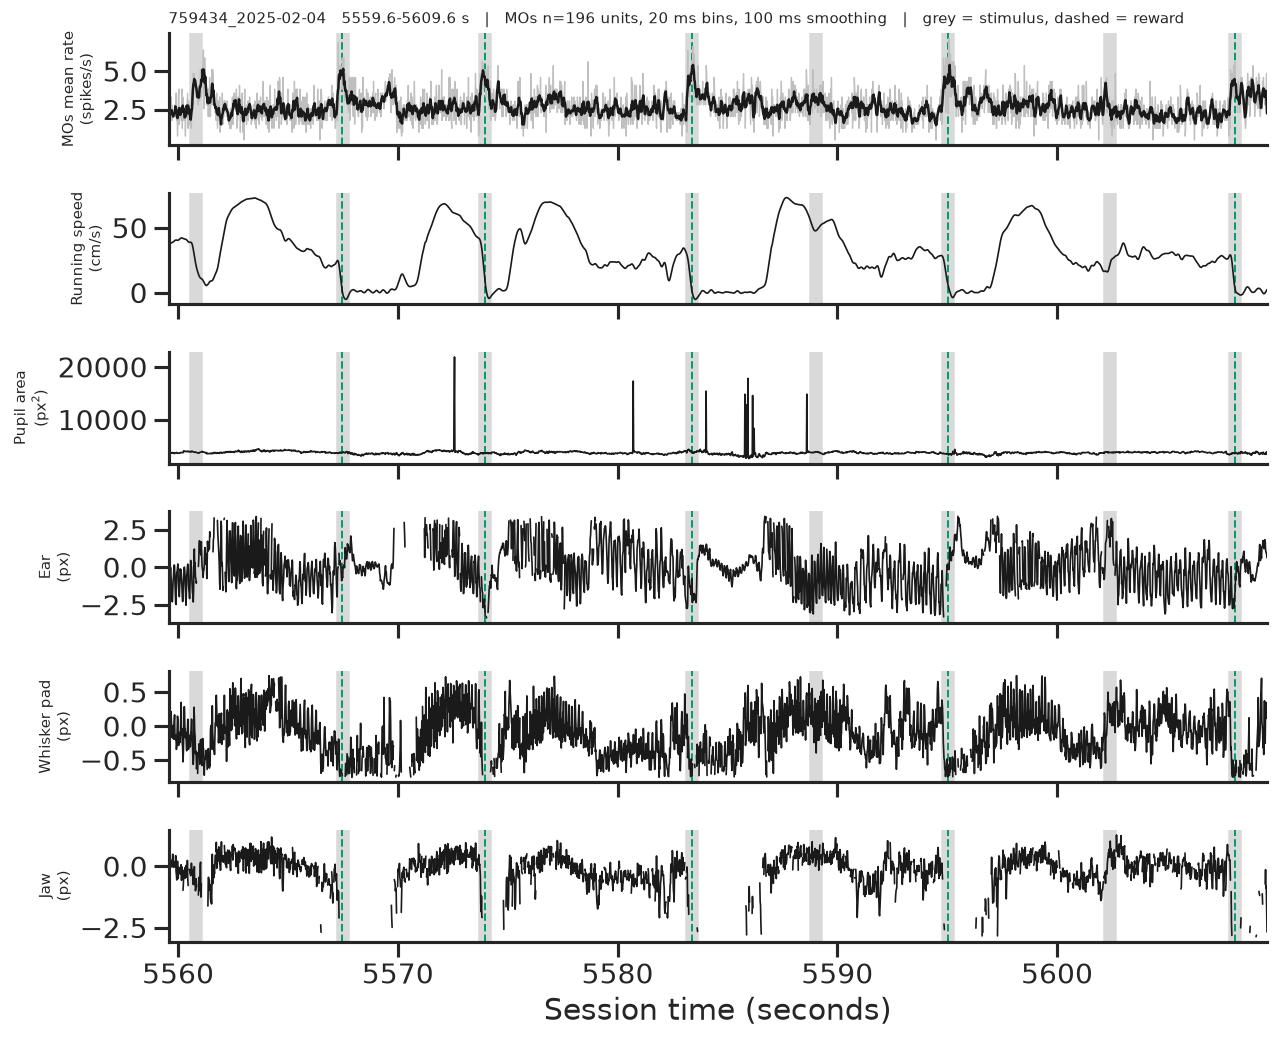

In [87]:
STIM_COLOR = '0.85'
REWARD_COLOR = palette[2]

window_rewards = task_reward_time_array[
    (task_reward_time_array >= WINDOW_START) & (task_reward_time_array < WINDOW_STOP)]

panel_labels = ['MOs mean rate\n(spikes/s)'] + list(window_streams.keys())
fig, axes = plt.subplots(len(panel_labels), 1, figsize=(11, 9), sharex=True)

# raw rate in grey behind the smoothed trace, so smoothing is visible not hidden
axes[0].plot(rate_time, mos_rate, color='0.75', lw=0.8)
axes[0].plot(rate_time, mos_rate_smoothed, color='k', lw=1.5)
axes[0].set_ylabel(panel_labels[0], fontsize=9)

for panel_index, (panel_label, (t, v)) in enumerate(window_streams.items(), start=1):
    axes[panel_index].plot(t, v, color='k', lw=1)
    axes[panel_index].set_ylabel(panel_label, fontsize=9)

for ax in axes:
    for _, trial_row in window_trials.iterrows():
        ax.axvspan(trial_row.stim_start_time, trial_row.stim_stop_time,
                   color=STIM_COLOR, zorder=0)
    for reward_time in window_rewards:
        ax.axvline(reward_time, color=REWARD_COLOR, lw=1.2, ls='--', zorder=1)
    sns.despine(ax=ax)

axes[-1].set_xlim(WINDOW_START, WINDOW_STOP)
axes[-1].set_xlabel('Session time (seconds)')
axes[0].set_title('%s   %.1f-%.1f s   |   MOs n=%d units, %d ms bins, %d ms smoothing   |   '
                  'grey = stimulus, dashed = reward'
                  % (session_id, WINDOW_START, WINDOW_STOP,
                     len(this_structure_units_table), BIN_WIDTH * 1e3,
                     BIN_WIDTH * SMOOTH_BINS * 1e3),
                  fontsize=9)
fig.tight_layout()
plt.show()

In [88]:
def time_since_last_reward(query_time_array, reward_time_array):
    """Seconds elapsed since the most recent reward at or before each query time.

    Resets to 0 at every reward and increases continuously between rewards.
    NaN before the first reward, where the quantity is undefined rather than zero.
    Reward times must be sorted.
    """
    query_time_array = np.asarray(query_time_array, dtype=float)
    preceding_index = np.searchsorted(reward_time_array, query_time_array,
                                      side='right') - 1
    elapsed = np.full(query_time_array.shape, np.nan)
    has_preceding = preceding_index >= 0
    elapsed[has_preceding] = (query_time_array[has_preceding]
                              - reward_time_array[preceding_index[has_preceding]])
    return elapsed


# evaluated on the neural rate grid so the panels share one time base
time_since_reward = time_since_last_reward(rate_time, task_reward_time_array)

# session-wide trial-level version, for later modelling
trials['time_since_reward_at_stim'] = time_since_last_reward(
    trials.stim_start_time.values, task_reward_time_array)

print('window: time since reward %.2f-%.2f s, %d resets'
      % (np.nanmin(time_since_reward), np.nanmax(time_since_reward),
         np.sum(np.diff(time_since_reward) < 0)))
print('session, at stimulus onset: median %.2f s, max %.2f s, NaN (before first reward) %d'
      % (trials.time_since_reward_at_stim.median(),
         trials.time_since_reward_at_stim.max(),
         int(trials.time_since_reward_at_stim.isna().sum())))
print('')
print('by outcome (s since last reward at stimulus onset):')
print(trials.groupby('outcome').time_since_reward_at_stim
      .describe()[['count', 'mean', '50%', 'max']])

window: time since reward 0.00-72.57 s, 5 resets
session, at stimulus onset: median 19.08 s, max 95.27 s, NaN (before first reward) 1

by outcome (s since last reward at stimulus onset):
                count       mean        50%        max
outcome                                               
correct reject  313.0  22.633650  19.009360  75.523235
false alarm      40.0  25.973975  17.940180  89.151280
hit             141.0  25.114187  19.773640  95.270500
miss              2.0  15.813405  15.813405  25.731740
unscored         48.0  24.134419  20.535497  77.708510


In [89]:
RT_CLIP_PERCENTILES = (5, 95)     # clip before scaling, so outliers don't set the range
MARKER_AREA_RANGE = (20, 200)     # points^2; linear in AREA, so diameter grows as sqrt(RT)
MARKER_OFFSET_STEPS = 1           # place markers this many bins before the event

rt_clip_low, rt_clip_high = np.percentile(reaction_time_array, RT_CLIP_PERCENTILES)
print('RT clip range: %.3f-%.3f s (%dth-%dth percentile of %d response trials)'
      % (rt_clip_low, rt_clip_high, RT_CLIP_PERCENTILES[0], RT_CLIP_PERCENTILES[1],
         reaction_time_array.size))


def reaction_time_to_marker_area(rt_array, clip_low=rt_clip_low, clip_high=rt_clip_high,
                                 area_range=MARKER_AREA_RANGE):
    """Map reaction time to matplotlib marker area (points^2), linearly.

    RTs are clipped to [clip_low, clip_high] first, so a single slow trial does
    not set the scale. Linear in area means diameter grows as sqrt(RT), which
    keeps small RT differences from being visually exaggerated.
    """
    normalised = (np.clip(np.asarray(rt_array, dtype=float), clip_low, clip_high)
                  - clip_low) / (clip_high - clip_low)
    return area_range[0] + normalised * (area_range[1] - area_range[0])


# print the mapping so it is transparent rather than implicit
print('\nRT (s) -> marker area (points^2) -> diameter (points)')
for probe_rt in [0.10, 0.20, 0.30, 0.40, 0.60, 0.90]:
    area = reaction_time_to_marker_area(probe_rt)
    print('  %.2f -> %6.1f -> %.1f' % (probe_rt, area, np.sqrt(area)))

RT clip range: 0.180-0.635 s (5th-95th percentile of 183 response trials)

RT (s) -> marker area (points^2) -> diameter (points)
  0.10 ->   20.0 -> 4.5
  0.20 ->   27.9 -> 5.3
  0.30 ->   67.4 -> 8.2
  0.40 ->  107.0 -> 10.3
  0.60 ->  186.1 -> 13.6
  0.90 ->  200.0 -> 14.1


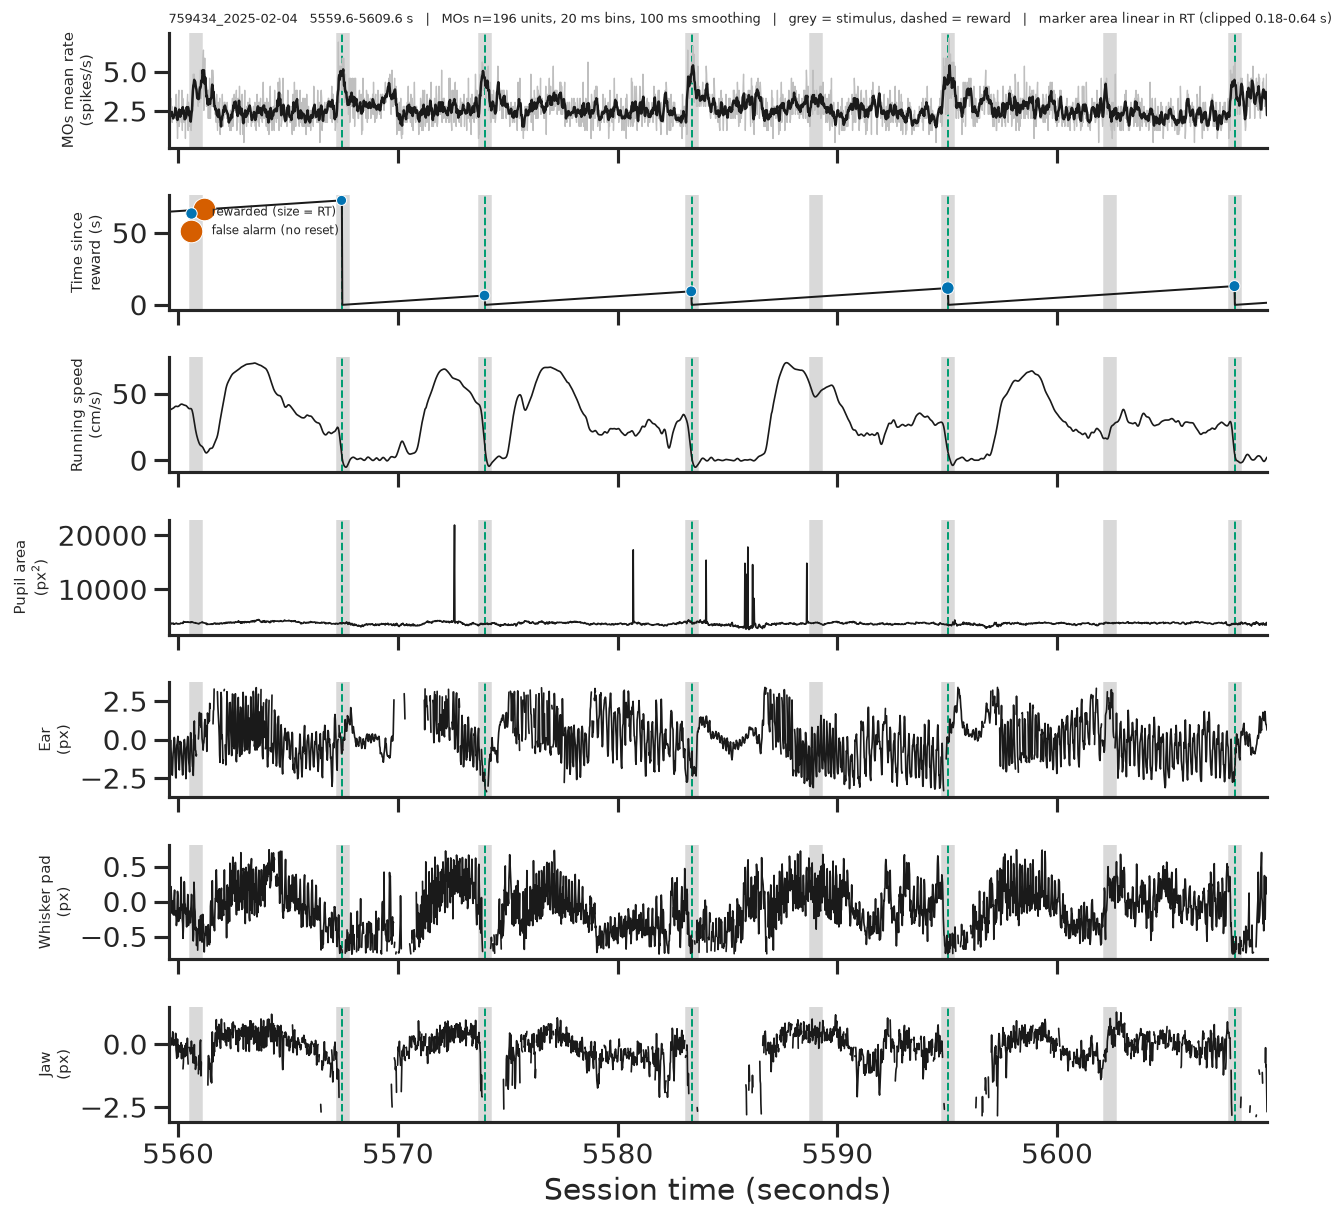

In [90]:
STIM_COLOR = '0.85'
REWARD_COLOR = palette[2]
MARKER_COLOR_REWARDED = palette[0]
MARKER_COLOR_FALSE_ALARM = palette[3]

window_rewards = task_reward_time_array[
    (task_reward_time_array >= WINDOW_START) & (task_reward_time_array < WINDOW_STOP)]

# rewarded trials: marker one time step before the reward, at the sawtooth peak
marker_offset = MARKER_OFFSET_STEPS * BIN_WIDTH
rewarded_in_window = window_trials[window_trials.reward_time.notna()
                                   & window_trials.reaction_time.notna()]
rewarded_marker_time = rewarded_in_window.reward_time.values - marker_offset
rewarded_marker_y = time_since_last_reward(rewarded_marker_time, task_reward_time_array)

# false alarms produce no reward and no reset, so they are placed at their own
# response time and coloured differently: the alignment is not the same quantity
false_alarm_in_window = window_trials[window_trials.is_false_alarm
                                      & window_trials.reaction_time.notna()]
false_alarm_marker_time = false_alarm_in_window.response_time.values
false_alarm_marker_y = time_since_last_reward(false_alarm_marker_time,
                                              task_reward_time_array)

panel_labels = (['MOs mean rate\n(spikes/s)', 'Time since\nreward (s)']
                + list(window_streams.keys()))
fig, axes = plt.subplots(len(panel_labels), 1, figsize=(11, 10.5), sharex=True)

# panel 0: neural, raw in grey behind smoothed
axes[0].plot(rate_time, mos_rate, color='0.75', lw=0.8)
axes[0].plot(rate_time, mos_rate_smoothed, color='k', lw=1.5)
axes[0].set_ylabel(panel_labels[0], fontsize=9)

# panel 1: time since last reward, with RT markers
axes[1].plot(rate_time, time_since_reward, color='k', lw=1.2)
axes[1].scatter(rewarded_marker_time, rewarded_marker_y,
                s=reaction_time_to_marker_area(rewarded_in_window.reaction_time.values),
                color=MARKER_COLOR_REWARDED, edgecolor='white', linewidth=0.6,
                zorder=3, label='rewarded (size = RT)')
if len(false_alarm_in_window):
    axes[1].scatter(false_alarm_marker_time, false_alarm_marker_y,
                    s=reaction_time_to_marker_area(
                        false_alarm_in_window.reaction_time.values),
                    color=MARKER_COLOR_FALSE_ALARM, edgecolor='white', linewidth=0.6,
                    zorder=3, label='false alarm (no reset)')
axes[1].set_ylabel(panel_labels[1], fontsize=9)
axes[1].legend(fontsize=7, frameon=False, loc='upper left')

# behavioral panels
for panel_index, (panel_label, (t, v)) in enumerate(window_streams.items(), start=2):
    axes[panel_index].plot(t, v, color='k', lw=1)
    axes[panel_index].set_ylabel(panel_label, fontsize=9)

for ax in axes:
    for _, trial_row in window_trials.iterrows():
        ax.axvspan(trial_row.stim_start_time, trial_row.stim_stop_time,
                   color=STIM_COLOR, zorder=0)
    for reward_time in window_rewards:
        ax.axvline(reward_time, color=REWARD_COLOR, lw=1.2, ls='--', zorder=1)
    sns.despine(ax=ax)

axes[-1].set_xlim(WINDOW_START, WINDOW_STOP)
axes[-1].set_xlabel('Session time (seconds)')
axes[0].set_title('%s   %.1f-%.1f s   |   MOs n=%d units, %d ms bins, %d ms smoothing   |   '
                  'grey = stimulus, dashed = reward   |   marker area linear in RT '
                  '(clipped %.2f-%.2f s)'
                  % (session_id, WINDOW_START, WINDOW_STOP,
                     len(this_structure_units_table), BIN_WIDTH * 1e3,
                     BIN_WIDTH * SMOOTH_BINS * 1e3, rt_clip_low, rt_clip_high),
                  fontsize=8)
fig.tight_layout()
plt.show()